In [64]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

In [26]:
df = pd.read_csv('tcmb_aylik_veriler.csv')
df.head()

,Tarih,tuketici_kredisi_faizi,1_aylik_mevduat_faizi,3_aylik_mevduat_faizi,usd_mevduat_faizi,eur_mevduat_faizi,tuketici_fiyat_endeksi,yurtici_uretici_fiyat_endeksi,ito_gecinme_endeksi,reel_kesim_guven_endeksi,istihdam_orani,issizlik_orani,konut_fiyat_endeksi,toplam_sifir_konut_satisi,toplam_ikinciel_konut_satisi,resmi_rezerv_varliklari,toplam_binek_otomobil_uretimi,usd_try,eur_try,gbp_try
0,2020-1,14.606,9.3120,10.2000,1.3680,0.1680,446.45,462.42,22278.1,104.1,43.5,14.1,120.9,38888.0,81178.0,102467.0,75396.0,5.918159,6.575059,7.722950
1,2020-2,13.835,8.9775,9.8775,1.1675,0.1425,448.02,464.64,22530.4,106.9,43.6,13.5,123.7,40309.0,85100.0,107724.0,87589.0,6.044470,6.593900,7.831265
2,2020-3,14.040,8.9725,10.0850,0.9550,0.1300,450.58,468.69,22604.2,99.7,41.9,13.0,125.4,36901.0,77895.0,92145.0,72093.0,6.314432,6.988741,7.818009
3,2020-4,12.065,8.7625,10.0575,1.0950,0.1725,454.43,474.69,22838.6,66.8,40.3,12.8,127.5,16007.0,29211.0,86343.0,9661.0,6.818952,7.416767,8.449205
4,2020-5,10.682,7.3260,8.3060,0.7540,0.1820,460.62,482.02,23332.7,76.9,41.0,12.6,135.9,19497.0,35708.0,90914.0,43264.0,6.951947,7.559518,8.543576


In [27]:
len(df)

75

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75 entries, 0 to 74
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Tarih                          75 non-null     object 
 1   tuketici_kredisi_faizi         75 non-null     float64
 2   1_aylik_mevduat_faizi          75 non-null     float64
 3   3_aylik_mevduat_faizi          75 non-null     float64
 4   usd_mevduat_faizi              75 non-null     float64
 5   eur_mevduat_faizi              75 non-null     float64
 6   tuketici_fiyat_endeksi         73 non-null     float64
 7   yurtici_uretici_fiyat_endeksi  74 non-null     float64
 8   ito_gecinme_endeksi            74 non-null     float64
 9   reel_kesim_guven_endeksi       75 non-null     float64
 10  istihdam_orani                 73 non-null     float64
 11  issizlik_orani                 73 non-null     float64
 12  konut_fiyat_endeksi            53 non-null     float

In [30]:
print(df.shape)

(75, 20)


In [31]:
df.describe()

,tuketici_kredisi_faizi,1_aylik_mevduat_faizi,3_aylik_mevduat_faizi,usd_mevduat_faizi,eur_mevduat_faizi,tuketici_fiyat_endeksi,yurtici_uretici_fiyat_endeksi,ito_gecinme_endeksi,reel_kesim_guven_endeksi,istihdam_orani,issizlik_orani,konut_fiyat_endeksi,toplam_sifir_konut_satisi,toplam_ikinciel_konut_satisi,resmi_rezerv_varliklari,toplam_binek_otomobil_uretimi,usd_try,eur_try,gbp_try
count,75.000000,75.000000,75.000000,75.000000,75.000000,73.000000,74.000000,74.000000,75.000000,73.000000,73.000000,53.000000,74.000000,74.000000,74.000000,74.000000,75.000000,75.000000,75.000000
mean,40.677704,29.029304,32.991896,1.678984,0.767700,1535.025205,2269.320946,98349.866216,103.396000,47.045205,10.319178,516.154717,43342.135135,88007.202703,125037.675676,71602.081081,22.267138,24.684126,28.689139
std,20.994902,17.623760,18.598830,0.682932,0.378741,1029.471494,1481.868800,75962.681653,6.909012,2.564449,1.867385,401.729412,15591.246238,26959.023874,31782.284278,16388.232602,12.722401,14.357487,16.756642
min,10.682000,6.946000,8.120000,0.550000,0.130000,446.450000,462.420000,22278.100000,66.800000,40.300000,7.600000,120.900000,16007.000000,29211.000000,79680.000000,9661.000000,5.918159,6.575059,7.722950
25%,22.263250,15.169250,17.594250,1.117500,0.426250,557.360000,715.527500,27655.500000,100.650000,45.900000,8.600000,161.700000,34849.000000,73076.000000,101365.750000,63065.500000,8.554282,10.161425,11.801377
50%,30.878000,17.442500,26.755000,1.685000,0.812500,1203.480000,2121.605000,70835.000000,103.700000,47.900000,10.100000,347.700000,40511.000000,83359.500000,119506.000000,74455.500000,18.823310,20.195714,22.855555
75%,60.372500,47.463000,51.325250,2.163750,1.097500,2394.100000,3595.602500,157094.750000,107.500000,49.200000,12.000000,847.400000,48706.000000,100679.250000,146799.500000,83552.750000,33.765026,36.574821,43.479882
max,79.147500,56.198000,67.567500,2.924000,1.360000,3683.830000,5029.760000,267302.800000,114.800000,50.300000,14.600000,1273.500000,101721.000000,169003.000000,218158.000000,96922.000000,44.058210,51.582955,59.185355


In [35]:
df.corr(numeric_only=True)

,tuketici_kredisi_faizi,1_aylik_mevduat_faizi,3_aylik_mevduat_faizi,usd_mevduat_faizi,eur_mevduat_faizi,tuketici_fiyat_endeksi,yurtici_uretici_fiyat_endeksi,ito_gecinme_endeksi,reel_kesim_guven_endeksi,istihdam_orani,issizlik_orani,konut_fiyat_endeksi,toplam_sifir_konut_satisi,toplam_ikinciel_konut_satisi,resmi_rezerv_varliklari,toplam_binek_otomobil_uretimi,usd_try,eur_try,gbp_try
tuketici_kredisi_faizi,1.000000,0.975334,0.986722,0.453931,0.813236,0.897425,0.910839,0.867410,-0.116044,0.806601,-0.875350,0.921942,-0.013304,-0.014423,0.772135,0.179524,0.921977,0.902625,0.910772
1_aylik_mevduat_faizi,0.975334,1.000000,0.984380,0.308981,0.741272,0.921567,0.909273,0.900042,-0.129513,0.745544,-0.826827,0.851241,0.030361,0.041956,0.812131,0.140610,0.918266,0.908857,0.917740
3_aylik_mevduat_faizi,0.986722,0.984380,1.000000,0.410280,0.768645,0.898163,0.904510,0.868027,-0.120417,0.793827,-0.861851,0.918809,-0.002403,-0.009360,0.772937,0.189396,0.911267,0.894137,0.902251
usd_mevduat_faizi,0.453931,0.308981,0.410280,1.000000,0.792221,0.379957,0.473616,0.344582,-0.145757,0.535574,-0.561160,0.783877,-0.156640,-0.270155,0.250539,0.297370,0.473473,0.434646,0.427403
eur_mevduat_faizi,0.813236,0.741272,0.768645,0.792221,1.000000,0.763275,0.812368,0.739711,-0.132657,0.721645,-0.799583,0.814877,-0.056969,-0.105456,0.616904,0.242896,0.820404,0.796514,0.796138
tuketici_fiyat_endeksi,0.897425,0.921567,0.898163,0.379957,0.763275,1.000000,0.988282,0.998706,-0.201125,0.741925,-0.856324,0.988094,0.117101,0.131591,0.928788,0.129085,0.984690,0.989988,0.990314
yurtici_uretici_fiyat_endeksi,0.910839,0.909273,0.904510,0.473616,0.812368,0.988282,1.000000,0.981026,-0.183269,0.814767,-0.908936,0.989335,0.089059,0.097444,0.913681,0.140101,0.997238,0.994628,0.994828
ito_gecinme_endeksi,0.867410,0.900042,0.868027,0.344582,0.739711,0.998706,0.981026,1.000000,-0.196726,0.715163,-0.836037,0.988572,0.114354,0.138298,0.935438,0.106991,0.975321,0.984522,0.983885
reel_kesim_guven_endeksi,-0.116044,-0.129513,-0.120417,-0.145757,-0.132657,-0.201125,-0.183269,-0.196726,1.000000,0.117540,0.097069,-0.040522,0.034861,0.124726,-0.137766,0.246266,-0.185670,-0.173737,-0.171218
istihdam_orani,0.806601,0.745544,0.793827,0.535574,0.721645,0.741925,0.814767,0.715163,0.117540,1.000000,-0.919194,0.823861,0.137300,0.153497,0.710771,0.201334,0.816386,0.792392,0.797398


<Axes: >

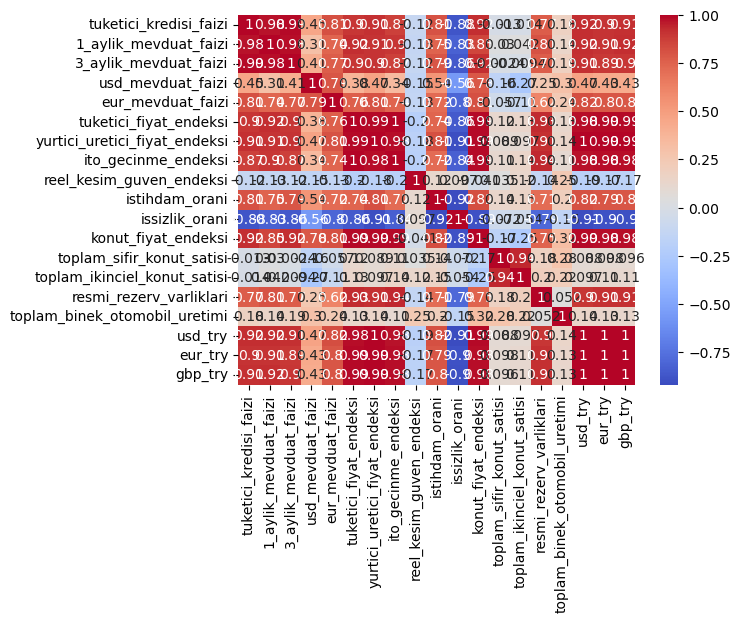

In [43]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

In [53]:
nan_percentage = df.isna().sum() / df.count() * 100

In [54]:
nan_count = df.isna().sum()

In [56]:
nan_table = pd.concat([nan_percentage,nan_count], axis=1)

In [59]:
nan_table.columns = ['Percantage', 'Count']

In [60]:
nan_table

,Percantage,Count
Tarih,0.000000,0
tuketici_kredisi_faizi,0.000000,0
1_aylik_mevduat_faizi,0.000000,0
3_aylik_mevduat_faizi,0.000000,0
usd_mevduat_faizi,0.000000,0
eur_mevduat_faizi,0.000000,0
tuketici_fiyat_endeksi,2.739726,2
yurtici_uretici_fiyat_endeksi,1.351351,1
ito_gecinme_endeksi,1.351351,1
reel_kesim_guven_endeksi,0.000000,0


In [61]:
!pip install scikit-learn

In [65]:
imputer = SimpleImputer(strategy= 'most_frequent')


In [66]:
df.iloc[:,:] = imputer.fit_transform(df)

In [67]:
df.isna().sum()

Tarih                            0
tuketici_kredisi_faizi           0
1_aylik_mevduat_faizi            0
3_aylik_mevduat_faizi            0
usd_mevduat_faizi                0
eur_mevduat_faizi                0
tuketici_fiyat_endeksi           0
yurtici_uretici_fiyat_endeksi    0
ito_gecinme_endeksi              0
reel_kesim_guven_endeksi         0
istihdam_orani                   0
issizlik_orani                   0
konut_fiyat_endeksi              0
toplam_sifir_konut_satisi        0
toplam_ikinciel_konut_satisi     0
resmi_rezerv_varliklari          0
toplam_binek_otomobil_uretimi    0
usd_try                          0
eur_try                          0
gbp_try                          0
dtype: int64

In [68]:
df.head()

,Tarih,tuketici_kredisi_faizi,1_aylik_mevduat_faizi,3_aylik_mevduat_faizi,usd_mevduat_faizi,eur_mevduat_faizi,tuketici_fiyat_endeksi,yurtici_uretici_fiyat_endeksi,ito_gecinme_endeksi,reel_kesim_guven_endeksi,istihdam_orani,issizlik_orani,konut_fiyat_endeksi,toplam_sifir_konut_satisi,toplam_ikinciel_konut_satisi,resmi_rezerv_varliklari,toplam_binek_otomobil_uretimi,usd_try,eur_try,gbp_try
0,2020-1,14.606,9.3120,10.2000,1.3680,0.1680,446.45,462.42,22278.1,104.1,43.5,14.1,120.9,38888.0,81178.0,102467.0,75396.0,5.918159,6.575059,7.722950
1,2020-2,13.835,8.9775,9.8775,1.1675,0.1425,448.02,464.64,22530.4,106.9,43.6,13.5,123.7,40309.0,85100.0,107724.0,87589.0,6.044470,6.593900,7.831265
2,2020-3,14.040,8.9725,10.0850,0.9550,0.1300,450.58,468.69,22604.2,99.7,41.9,13.0,125.4,36901.0,77895.0,92145.0,72093.0,6.314432,6.988741,7.818009
3,2020-4,12.065,8.7625,10.0575,1.0950,0.1725,454.43,474.69,22838.6,66.8,40.3,12.8,127.5,16007.0,29211.0,86343.0,9661.0,6.818952,7.416767,8.449205
4,2020-5,10.682,7.3260,8.3060,0.7540,0.1820,460.62,482.02,23332.7,76.9,41.0,12.6,135.9,19497.0,35708.0,90914.0,43264.0,6.951947,7.559518,8.543576
